<a href="https://www.kaggle.com/code/sonawanelalitsunil/amazon-sales-snapshot-2025-ml-48?scriptVersionId=232425447" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/amazon-sales-2025/amazon_sales_data 2025.csv


## Title: Amazon Sales Snapshot 2025

#### Description: A concise overview of Amazon's sales trends, top-performing categories, and key growth highlights in 2025.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/amazon-sales-2025/amazon_sales_data 2025.csv')

In [3]:
df.head()

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status
0,ORD0001,14-03-25,Running Shoes,Footwear,60,3,180,Emma Clark,New York,Debit Card,Cancelled
1,ORD0002,20-03-25,Headphones,Electronics,100,4,400,Emily Johnson,San Francisco,Debit Card,Pending
2,ORD0003,15-02-25,Running Shoes,Footwear,60,2,120,John Doe,Denver,Amazon Pay,Cancelled
3,ORD0004,19-02-25,Running Shoes,Footwear,60,3,180,Olivia Wilson,Dallas,Credit Card,Pending
4,ORD0005,10-03-25,Smartwatch,Electronics,150,3,450,Emma Clark,New York,Debit Card,Pending


In [4]:
df.tail()

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status
245,ORD0246,17-03-25,T-Shirt,Clothing,20,2,40,Daniel Harris,Miami,Debit Card,Cancelled
246,ORD0247,30-03-25,Jeans,Clothing,40,1,40,Sophia Miller,Dallas,Debit Card,Cancelled
247,ORD0248,05-03-25,T-Shirt,Clothing,20,2,40,Chris White,Denver,Debit Card,Cancelled
248,ORD0249,08-03-25,Smartwatch,Electronics,150,3,450,Emily Johnson,New York,Debit Card,Cancelled
249,ORD0250,19-02-25,Smartphone,Electronics,500,4,2000,Emily Johnson,Seattle,Amazon Pay,Completed


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Order ID           250 non-null    object
 1   Date               250 non-null    object
 2   Product            250 non-null    object
 3   Category           250 non-null    object
 4   Price              250 non-null    int64 
 5   Quantity           250 non-null    int64 
 6   Total Sales        250 non-null    int64 
 7   Customer Name      250 non-null    object
 8   Customer Location  250 non-null    object
 9   Payment Method     250 non-null    object
 10  Status             250 non-null    object
dtypes: int64(3), object(8)
memory usage: 21.6+ KB


In [6]:
df.describe()

,Price,Quantity,Total Sales
count,250.000000,250.000000,250.000000
mean,343.580000,2.856000,975.380000
std,380.635808,1.429489,1252.112254
min,15.000000,1.000000,15.000000
25%,40.000000,2.000000,100.000000
50%,150.000000,3.000000,400.000000
75%,600.000000,4.000000,1500.000000
max,1200.000000,5.000000,6000.000000


In [7]:
df.isnull().sum()

Order ID             0
Date                 0
Product              0
Category             0
Price                0
Quantity             0
Total Sales          0
Customer Name        0
Customer Location    0
Payment Method       0
Status               0
dtype: int64

In [8]:
df.shape

(250, 11)

In [9]:
df.duplicated().sum()

0

In [10]:
df.dtypes

Order ID             object
Date                 object
Product              object
Category             object
Price                 int64
Quantity              int64
Total Sales           int64
Customer Name        object
Customer Location    object
Payment Method       object
Status               object
dtype: object

In [11]:
df.columns

Index(['Order ID', 'Date', 'Product', 'Category', 'Price', 'Quantity',
       'Total Sales', 'Customer Name', 'Customer Location', 'Payment Method',
       'Status'],
      dtype='object')

## Data visualizations

In [12]:
# Ensure proper column types
df['Category'] = df['Category'].astype(str)
df['Product'] = df['Product'].astype(str)
df['Customer Location'] = df['Customer Location'].astype(str)
df['Payment Method'] = df['Payment Method'].astype(str)
df['Status'] = df['Status'].astype(str)

# Set visual style
sns.set(style="whitegrid", palette="pastel")

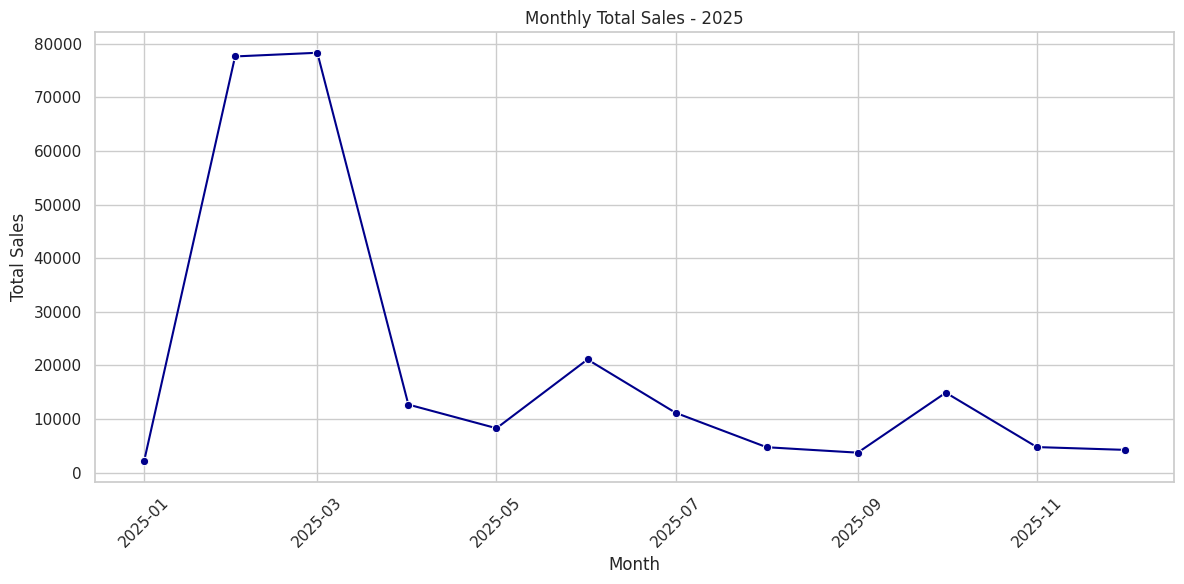

In [13]:
# Step 1: Ensure Date is datetime type
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Step 2: Drop rows where Date is NaT
df = df.dropna(subset=['Date'])

# Step 3: Group by month and sum sales
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Sales'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Date'].dt.to_timestamp()

# Step 4: Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='Date', y='Total Sales', marker='o', color='darkblue')
plt.title('Monthly Total Sales - 2025')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


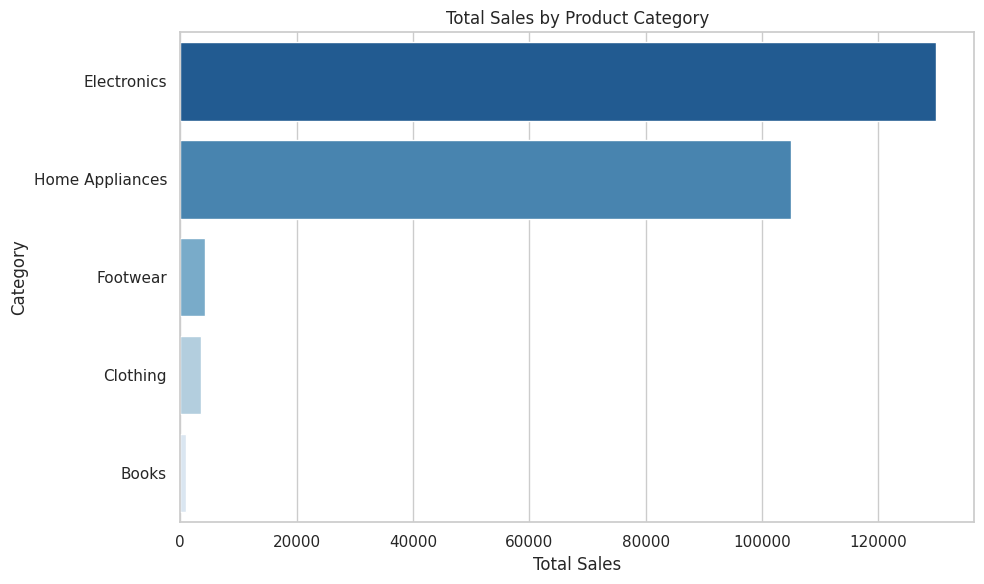

In [14]:
plt.figure(figsize=(10, 6))
category_sales = df.groupby('Category')['Total Sales'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.values, y=category_sales.index, palette='Blues_r')
plt.title('Total Sales by Product Category')
plt.xlabel('Total Sales')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

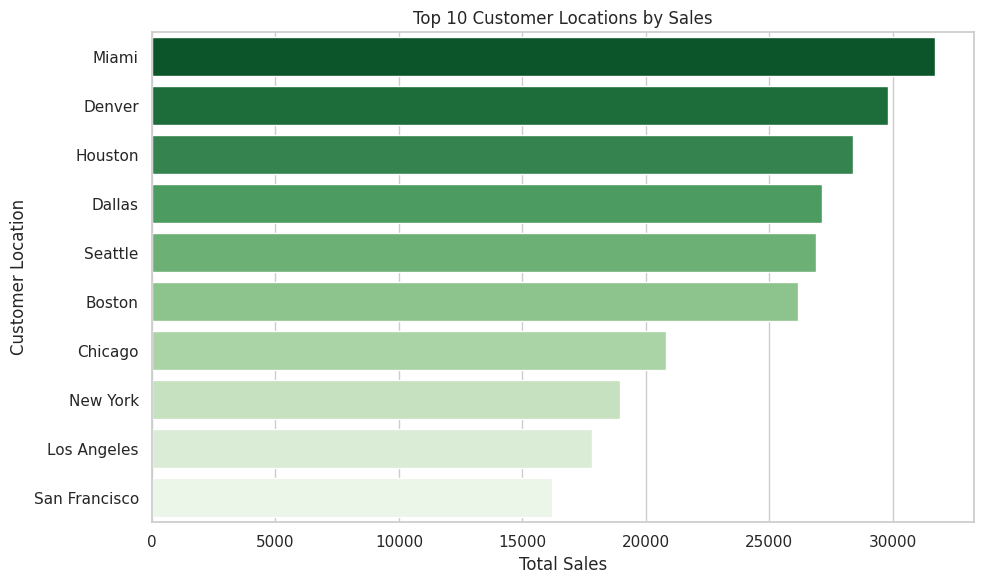

In [15]:
top_locations = df.groupby('Customer Location')['Total Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_locations.values, y=top_locations.index, palette='Greens_r')
plt.title('Top 10 Customer Locations by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Customer Location')
plt.tight_layout()
plt.show()


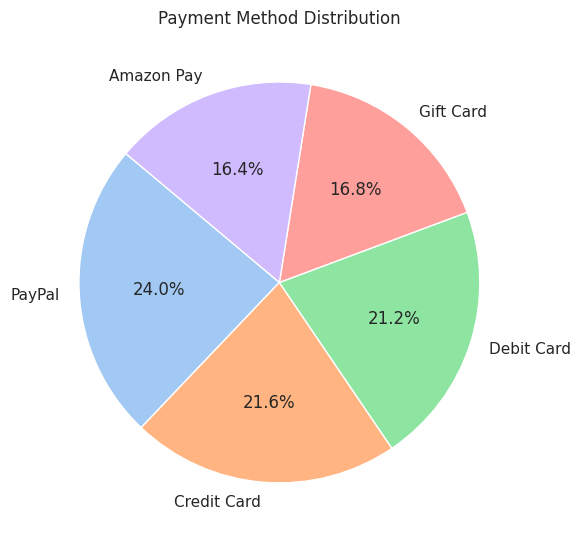

In [16]:
payment_counts = df['Payment Method'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('Payment Method Distribution')
plt.tight_layout()
plt.show()


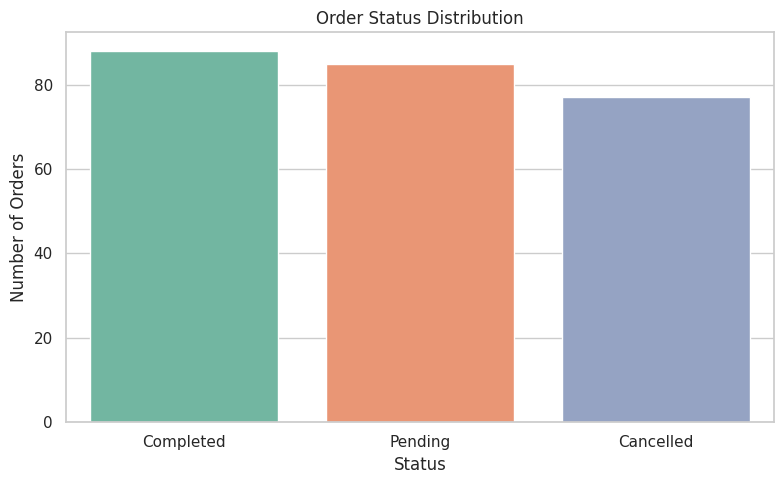

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Status', palette='Set2', order=df['Status'].value_counts().index)
plt.title('Order Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()


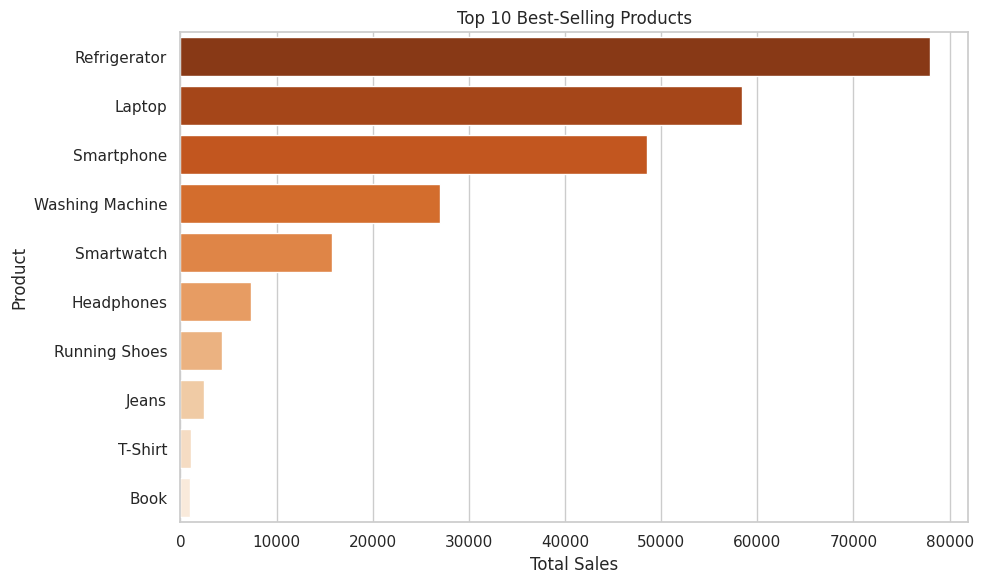

In [18]:
top_products = df.groupby('Product')['Total Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='Oranges_r')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.tight_layout()
plt.show()


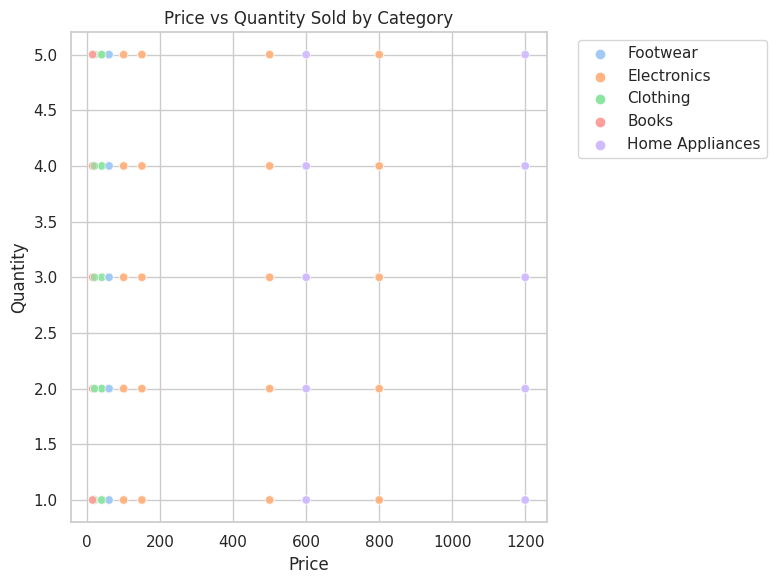

In [19]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Price', y='Quantity', hue='Category', alpha=0.7)
plt.title('Price vs Quantity Sold by Category')
plt.xlabel('Price')
plt.ylabel('Quantity')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [21]:
# ML Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [22]:
# 1. Preprocess Date
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df.drop(columns=['Date', 'Order ID', 'Customer Name'], inplace=True)  # Drop ID/name fields

In [23]:
# 2. Fill or drop missing
df.dropna(inplace=True)

In [24]:
# 3. Encode categorical features
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


In [25]:
# 4. Define features and target
X = df.drop('Status', axis=1)
y = df['Status']


In [26]:
# 5. Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# 6. Define models to test
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Support Vector Machine': SVC(),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

In [28]:
# 7. Train and evaluate
results = []

In [29]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    results.append((name, acc))
    
    print(f"📌 Model: {name}")
    print(f"✅ Accuracy: {acc:.2f}%")

📌 Model: Logistic Regression
✅ Accuracy: 34.00%
📌 Model: Random Forest
✅ Accuracy: 36.00%
📌 Model: Decision Tree
✅ Accuracy: 32.00%
📌 Model: Support Vector Machine
✅ Accuracy: 36.00%
📌 Model: Naive Bayes
✅ Accuracy: 48.00%
📌 Model: K-Nearest Neighbors
✅ Accuracy: 36.00%


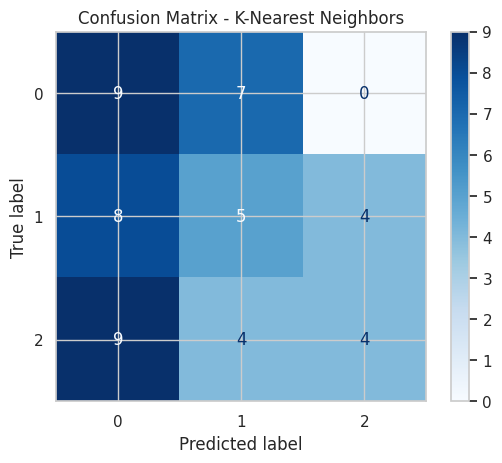

In [30]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix - {name}")
plt.show()

In [31]:
# 8. Summary of accuracies
summary_df = pd.DataFrame(results, columns=["Model", "Accuracy (%)"]).sort_values(by="Accuracy (%)", ascending=False)
print("\n🔍 Summary of Model Accuracies:\n")
print(summary_df)


🔍 Summary of Model Accuracies:

                    Model  Accuracy (%)
4             Naive Bayes          48.0
1           Random Forest          36.0
3  Support Vector Machine          36.0
5     K-Nearest Neighbors          36.0
0     Logistic Regression          34.0
2           Decision Tree          32.0


## Thank you..pls upvote!!!!